## Notebook 4: Model Evaluation

**Goal:** Evaluate and compare all 3 trained models using the right metrics.

**Input:** Trained models from `models/` + test data from `data/processed/`  
**Output:** Best model identified based on Precision, Recall, F1 and PR-AUC

### Evaluation Strategy

#### Why not Accuracy?
- Test data is still imbalanced (123 fraud vs 71,079 genuine)
- A model predicting everything as genuine gets 99.83% accuracy
  but catches zero fraud — completely useless

#### Metrics we use instead:
- **Precision** — of flagged fraud, how many are real fraud?
- **Recall** — of all real fraud, how many did we catch?
- **F1 Score** — balance between Precision and Recall
- **PR-AUC** — best metric for imbalanced classification
- **ROC-AUC** — overall model discrimination ability
- **Confusion Matrix** — visual of caught vs missed fraud

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             precision_recall_curve,
                             average_precision_score,
                             roc_auc_score)

In [2]:
lr_model  = joblib.load('../models/logistic_regression.pkl')
rf_model  = joblib.load('../models/random_forest.pkl')
xgb_model = joblib.load('../models/xgboost.pkl')

X_test = pd.read_csv('../data/processed/X_test.csv')
Y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("Models loaded successfully!")

Models loaded successfully!


In [3]:
lr_pred  = lr_model.predict(X_test)
rf_pred  = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

lr_prob  = lr_model.predict_proba(X_test)[:, 1]
rf_prob  = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"\nFraud predicted by Logistic Regression : {lr_pred.sum()}")
print(f"Fraud predicted by Random Forest       : {rf_pred.sum()}")
print(f"Fraud predicted by XGBoost             : {xgb_pred.sum()}")
print(f"\nActual fraud in test set               : {Y_test.sum()}")


Fraud predicted by Logistic Regression : 1821
Fraud predicted by Random Forest       : 116
Fraud predicted by XGBoost             : 138

Actual fraud in test set               : 123


In [4]:
models_pred = {
    'Logistic Regression': lr_pred,
    'Random Forest'      : rf_pred,
    'XGBoost'            : xgb_pred
}

for name, pred in models_pred.items():
    print(f"{'='*53}")
    print(f"  {name}")
    print(f"{'='*53}")
    print(classification_report(Y_test, pred,
                                target_names=['Genuine', 'Fraud']))

  Logistic Regression
              precision    recall  f1-score   support

     Genuine       1.00      0.98      0.99     71079
       Fraud       0.06      0.89      0.11       123

    accuracy                           0.98     71202
   macro avg       0.53      0.93      0.55     71202
weighted avg       1.00      0.98      0.99     71202

  Random Forest
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     71079
       Fraud       0.85      0.80      0.83       123

    accuracy                           1.00     71202
   macro avg       0.93      0.90      0.91     71202
weighted avg       1.00      1.00      1.00     71202

  XGBoost
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     71079
       Fraud       0.73      0.82      0.77       123

    accuracy                           1.00     71202
   macro avg       0.87      0.91      0.89     71202
weighted avg       1.00   

In [5]:
models_prob = {
    'Logistic Regression': lr_prob,
    'Random Forest'      : rf_prob,
    'XGBoost'            : xgb_prob
}

for name, prob in models_prob.items():
    pr_auc  = average_precision_score(Y_test, prob)
    roc_auc = roc_auc_score(Y_test, prob)
    print(f"{name:<20} PR-AUC: {pr_auc:.4f}  ROC-AUC: {roc_auc:.4f}")

Logistic Regression  PR-AUC: 0.7111  ROC-AUC: 0.9720
Random Forest        PR-AUC: 0.8515  ROC-AUC: 0.9740
XGBoost              PR-AUC: 0.8487  ROC-AUC: 0.9812


#### Results Summary

| Model | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|-------|--------|---------|-----|-----------|--------|
| Logistic Regression | 0.7111 | 0.9720 | 0.11 | 0.06 | 0.89 |
| Random Forest | 0.8515 | 0.9740 | 0.83 | 0.85 | 0.80 |
| XGBoost | 0.8487 | 0.9812 | 0.77 | 0.73 | 0.82 |

- Random Forest wins on PR-AUC (0.8515) and F1-Score (0.83)
- XGBoost wins on ROC-AUC (0.9812) and catches more fraud
- Logistic Regression too many false alarms — not production ready
- Full confusion matrix analysis needed before final decision

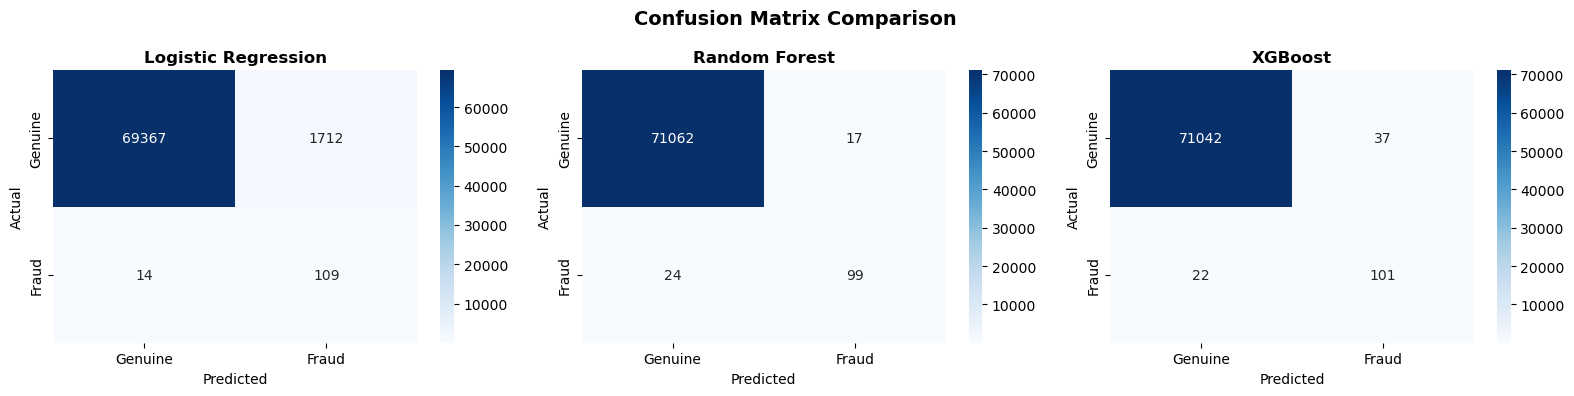

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models_pred = {
    'Logistic Regression': lr_pred,
    'Random Forest'      : rf_pred,
    'XGBoost'            : xgb_pred
}

for i, (name, pred) in enumerate(models_pred.items()):
    cm = confusion_matrix(Y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues',
                xticklabels=['Genuine', 'Fraud'],
                yticklabels=['Genuine', 'Fraud'],
                ax=axes[i])
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Who is the Best Model?

| Priority | Winner |
|----------|--------|
| Minimize false alarms | Random Forest (only 17 FP) |
| Catch maximum fraud | Logistic Regression (109 caught) |
| Best overall balance | XGBoost (101 caught, only 37 FP) |
| Best discrimination | XGBoost (ROC-AUC 0.9812) |

**Final Decision → XGBoost selected for deployment**
based on:
- Catches 101 fraud vs Random Forest 99
- Misses only 22 fraud vs Random Forest 24
- Best ROC-AUC (0.9812)
- In fraud detection missing real fraud is more 
  costly than false alarms

## Precision-Recall Curve
Visualizing model performance across all possible thresholds.

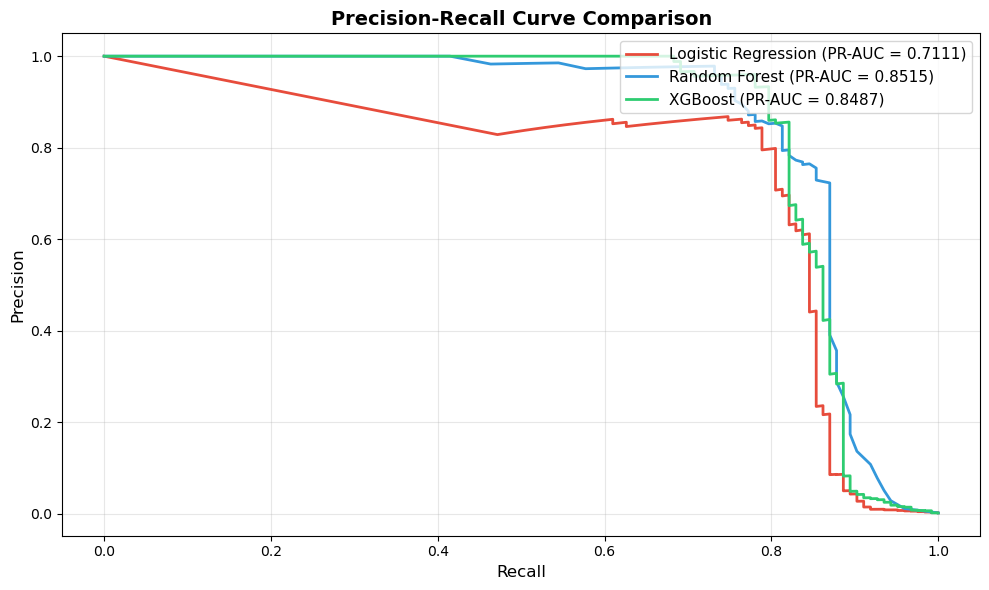

In [7]:
plt.figure(figsize=(10, 6))

models_prob = {
    'Logistic Regression': lr_prob,
    'Random Forest'      : rf_prob,
    'XGBoost'            : xgb_prob
}

colors = ['#e74c3c', '#3498db', '#2ecc71']

for (name, prob), color in zip(models_prob.items(), colors):
    precision, recall, _ = precision_recall_curve(Y_test, prob)
    pr_auc = average_precision_score(Y_test, prob)
    plt.plot(recall, precision, 
             color=color,
             label=f'{name} (PR-AUC = {pr_auc:.4f})',
             linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve Comparison', 
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### PR Curve Insights
- Random Forest maintains highest precision longest (blue curve)
- XGBoost almost identical to Random Forest
- Logistic Regression drops earliest — confirms weak precision
- All models collapse after recall 0.85 — optimal threshold
  is around 0.80 recall for best precision-recall balance

## Final Model Decision

Both Random Forest and XGBoost perform similarly:

| | Random Forest | XGBoost |
|--|--------------|---------|
| PR-AUC | 0.8515 ✅ | 0.8487 |
| ROC-AUC | 0.9740 | 0.9812 ✅ |
| F1-Score | 0.83 ✅ | 0.77 |
| Fraud caught | 99 | 101 ✅ |
| False alarms | 17 ✅ | 37 |

**Selected → XGBoost for deployment**
- Catches 2 more frauds than Random Forest
- In fraud detection, missing real fraud is more
  costly than extra false alarms
- ROC-AUC 0.9812 shows best overall discrimination

**Random Forest is recommended when:**
- Business priority is minimizing false alarms
- Investigation resources are limited